In [1]:
df <- read.csv('City_time_series.csv')
names(df)
# We do this to reduce the df size. There are so many entries that cleaning it
# in a separate file and exporting will let us run experiments faster.
colMeans(is.na(df)) * 100
features = c(
    "Date",
    "RegionName",
    "Sale_Counts_Seas_Adj",

    # Supply
    "InventorySeasonallyAdjusted_AllHomes",

    # Price
    "MedianListingPrice_AllHomes",

    # Rent Ratio (Substitute for ZRI_AllHomes)
    "PriceToRentRatio_AllHomes",

    # Sentiment (Using the NON-Seasonally Adjusted version to save rows)
    "PctOfListingsWithPriceReductions_AllHomes",
    "MedianPctOfPriceReduction_AllHomes",
    "ZHVI_AllHomes",
    "ZRI_AllHomes"
)
df <- df[!is.na(df$Sale_Counts_Seas_Adj), ]
df <- df[, features]
# drops remaining NAs
df <- na.omit(df)
nrow(df)
cat("\n")
str(df)
sapply(df, class)
num_unique_regions <- length(unique(df$RegionName))
num_unique_regions

[1] "Date"                                                         
 [2] "RegionName"                                                   
 [3] "InventorySeasonallyAdjusted_AllHomes"                         
 [4] "InventoryRaw_AllHomes"                                        
 [5] "MedianListingPricePerSqft_1Bedroom"                           
 [6] "MedianListingPricePerSqft_2Bedroom"                           
 [7] "MedianListingPricePerSqft_3Bedroom"                           
 [8] "MedianListingPricePerSqft_4Bedroom"                           
 [9] "MedianListingPricePerSqft_5BedroomOrMore"                     
[10] "MedianListingPricePerSqft_AllHomes"                           
[11] "MedianListingPricePerSqft_CondoCoop"                          
[12] "MedianListingPricePerSqft_DuplexTriplex"                      
[13] "MedianListingPricePerSqft_SingleFamilyResidence"              
[14] "MedianListingPrice_1Bedroom"                                  
[15] "MedianListingPrice_2Bedroom"                                  
[16] "MedianListingPrice_3Bedroom"                                  
[17] "MedianListingPrice_4Bedroom"                                  
[18] "MedianListingPrice_5BedroomOrMore"                            
[19] "MedianListingPrice_AllHomes"                                  
[20] "MedianListingPrice_CondoCoop"                                 
[21] "MedianListingPrice_DuplexTriplex"                             
[22] "MedianListingPrice_SingleFamilyResidence"                     
[23] "MedianPctOfPriceReduction_AllHomes"                           
[24] "MedianPctOfPriceReduction_CondoCoop"                          
[25] "MedianPctOfPriceReduction_SingleFamilyResidence"              
[26] "MedianPriceCutDollar_AllHomes"                                
[27] "MedianPriceCutDollar_CondoCoop"                               
[28] "MedianPriceCutDollar_SingleFamilyResidence"                   
[29] "MedianRentalPricePerSqft_1Bedroom"                            
[30] "MedianRentalPricePerSqft_2Bedroom"                            
[31] "MedianRentalPricePerSqft_3Bedroom"                            
[32] "MedianRentalPricePerSqft_4Bedroom"                            
[33] "MedianRentalPricePerSqft_5BedroomOrMore"                      
[34] "MedianRentalPricePerSqft_AllHomes"                            
[35] "MedianRentalPricePerSqft_CondoCoop"                           
[36] "MedianRentalPricePerSqft_DuplexTriplex"                       
[37] "MedianRentalPricePerSqft_MultiFamilyResidence5PlusUnits"      
[38] "MedianRentalPricePerSqft_SingleFamilyResidence"               
[39] "MedianRentalPricePerSqft_Studio"                              
[40] "MedianRentalPrice_1Bedroom"                                   
[41] "MedianRentalPrice_2Bedroom"                                   
[42] "MedianRentalPrice_3Bedroom"                                   
[43] "MedianRentalPrice_4Bedroom"                                   
[44] "MedianRentalPrice_5BedroomOrMore"                             
[45] "MedianRentalPrice_AllHomes"                                   
[46] "MedianRentalPrice_CondoCoop"                                  
[47] "MedianRentalPrice_DuplexTriplex"                              
[48] "MedianRentalPrice_MultiFamilyResidence5PlusUnits"             
[49] "MedianRentalPrice_SingleFamilyResidence"                      
[50] "MedianRentalPrice_Studio"                                     
[51] "ZHVIPerSqft_AllHomes"                                         
[52] "PctOfHomesDecreasingInValues_AllHomes"                        
[53] "PctOfHomesIncreasingInValues_AllHomes"                        
[54] "PctOfHomesSellingForGain_AllHomes"                            
[55] "PctOfHomesSellingForLoss_AllHomes"                            
[56] "PctOfListingsWithPriceReductionsSeasAdj_AllHomes"             
[57] "PctOfListingsWithPriceReductionsSeasAdj_CondoCoop"            
[58] "PctOfListingsWithPriceReductionsSeasAdj_SingleFamilyResidence"

Date 
                                                      0.00000 
                                                   RegionName 
                                                      0.00000 
                         InventorySeasonallyAdjusted_AllHomes 
                                                     79.48889 
                                        InventoryRaw_AllHomes 
                                                     79.48889 
                           MedianListingPricePerSqft_1Bedroom 
                                                     99.79615 
                           MedianListingPricePerSqft_2Bedroom 
                                                     98.01800 
                           MedianListingPricePerSqft_3Bedroom 
                                                     93.33877 
                           MedianListingPricePerSqft_4Bedroom 
                                                     96.16796 
                     MedianListingPricePerSqft_5BedroomOrMore 
                                                     98.99927 
                           MedianListingPricePerSqft_AllHomes 
                                                     85.32983 
                          MedianListingPricePerSqft_CondoCoop 
                                                     98.54299 
                      MedianListingPricePerSqft_DuplexTriplex 
                                                     99.79844 
              MedianListingPricePerSqft_SingleFamilyResidence 
                                                     85.87586 
                                  MedianListingPrice_1Bedroom 
                                                     99.82741 
                                  MedianListingPrice_2Bedroom 
                                                     98.46549 
                                  MedianListingPrice_3Bedroom 
                                                     94.43834 
                                  MedianListingPrice_4Bedroom 
                                                     96.80410 
                            MedianListingPrice_5BedroomOrMore 
                                                     99.23555 
                                  MedianListingPrice_AllHomes 
                                                     88.52087 
                                 MedianListingPrice_CondoCoop 
                                                     98.90678 
                             MedianListingPrice_DuplexTriplex 
                                                     99.78262 
                     MedianListingPrice_SingleFamilyResidence 
                                                     88.83408 
                           MedianPctOfPriceReduction_AllHomes 
                                                     92.46429 
                          MedianPctOfPriceReduction_CondoCoop 
                                                     99.45973 
              MedianPctOfPriceReduction_SingleFamilyResidence 
                                                     93.06303 
                                MedianPriceCutDollar_AllHomes 
                                                     92.46429 
                               MedianPriceCutDollar_CondoCoop 
                                                     99.45973 
                   MedianPriceCutDollar_SingleFamilyResidence 
                                                     93.06303 
                            MedianRentalPricePerSqft_1Bedroom 
                                                     99.59187 
                            MedianRentalPricePerSqft_2Bedroom 
                                                     99.17001 
                            MedianRentalPricePerSqft_3Bedroom 
                                                     99.07332 
                            MedianRentalPricePerSqft_4Bedroom 
                                                     99.73704 
                      Med

[1] 102238


'data.frame':	102238 obs. of  10 variables:
 $ Date                                     : chr  "2010-11-30" "2010-11-30" "2010-11-30" "2010-11-30" ...
 $ RegionName                               : chr  "aberdeenharfordmd" "abingdonharfordmd" "abingtonmontgomerypa" "advancedavienc" ...
 $ Sale_Counts_Seas_Adj                     : num  28 35 37 12 20 16 37 28 98 12 ...
 $ InventorySeasonallyAdjusted_AllHomes     : int  168 246 383 181 162 142 265 339 596 136 ...
 $ MedianListingPrice_AllHomes              : num  198950 225000 245450 249000 139900 ...
 $ PriceToRentRatio_AllHomes                : num  11.2 11.8 13.3 12.7 10.5 ...
 $ PctOfListingsWithPriceReductions_AllHomes: num  14.1 18.1 15.4 11.2 17.5 ...
 $ MedianPctOfPriceReduction_AllHomes       : num  4.55 3.94 3.72 3.41 3.39 ...
 $ ZHVI_AllHomes                            : int  205100 232400 247000 191000 137200 175500 141100 164300 278800 159800 ...
 $ ZRI_AllHomes                             : int  1413 1593 1629 1242 1106 13

Date 
                              "character" 
                               RegionName 
                              "character" 
                     Sale_Counts_Seas_Adj 
                                "numeric" 
     InventorySeasonallyAdjusted_AllHomes 
                                "integer" 
              MedianListingPrice_AllHomes 
                                "numeric" 
                PriceToRentRatio_AllHomes 
                                "numeric" 
PctOfListingsWithPriceReductions_AllHomes 
                                "numeric" 
       MedianPctOfPriceReduction_AllHomes 
                                "numeric" 
                            ZHVI_AllHomes 
                                "integer" 
                             ZRI_AllHomes 
                                "integer"

[1] 1677

[1] "Fetching pre-compiled GBM from Ubuntu servers..."


[1] "Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease"  
 [2] "Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease"                      
 [3] "Hit:3 https://cli.github.com/packages stable InRelease"                      
 [4] "Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease"                  
 [5] "Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease"              
 [6] "Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease"            
 [7] "Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease"
 [8] "Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease" 
 [9] "Hit:9 http://security.ubuntu.com/ubuntu jammy-security InRelease"            
[10] "Reading package lists..."

[1] "Reading package lists..."                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
  [2] "Building dependency tree..."                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
  [3] "Reading state information..."                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  
  [4] "The following additional packages will be installed:"                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
  [5] "  r-cran-abind r-cran-cardata r-cran-colorspace r-cran-cowplot r-cran-deriv"                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
  [6] "  r-cran-doby r-cran-forecast r-cran-formula r-cran-fracdiff r-cran-lme4"                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
  [7] "  r-cran-lmtest r-cran-matrixmodels r-cran-microbenchmark r-cran-minqa"                                          

[1] "Reading package lists..."                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
 [2] "Building dependency tree..."                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
 [3] "Reading state information..."                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  
 [4] "Suggested packages:"                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
 [5] "  r-cran-seriation r-cran-prettydoc"                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
 [6] "The following NEW packages will be installed:"                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
 [7] "  r-cran-corrplot"                                                                                                     

Loading required package: car

Loading required package: carData

Loading required package: ggplot2



[1] "All packages successfully installed and loaded."


[1] 102238

log_ListingPrice 
                                 1.183882 
                            log_Inventory 
                                 2.148360 
                          log_Sale_Counts 
                                 2.245125 
PctOfListingsWithPriceReductions_AllHomes 
                                 1.035433 
       MedianPctOfPriceReduction_AllHomes 
                                 1.314637

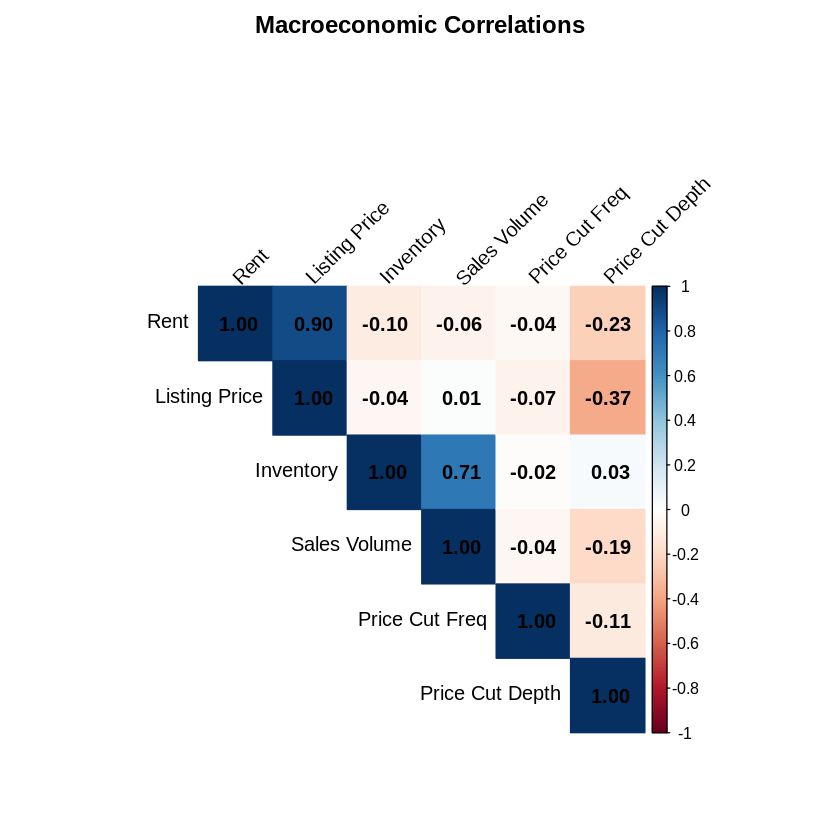

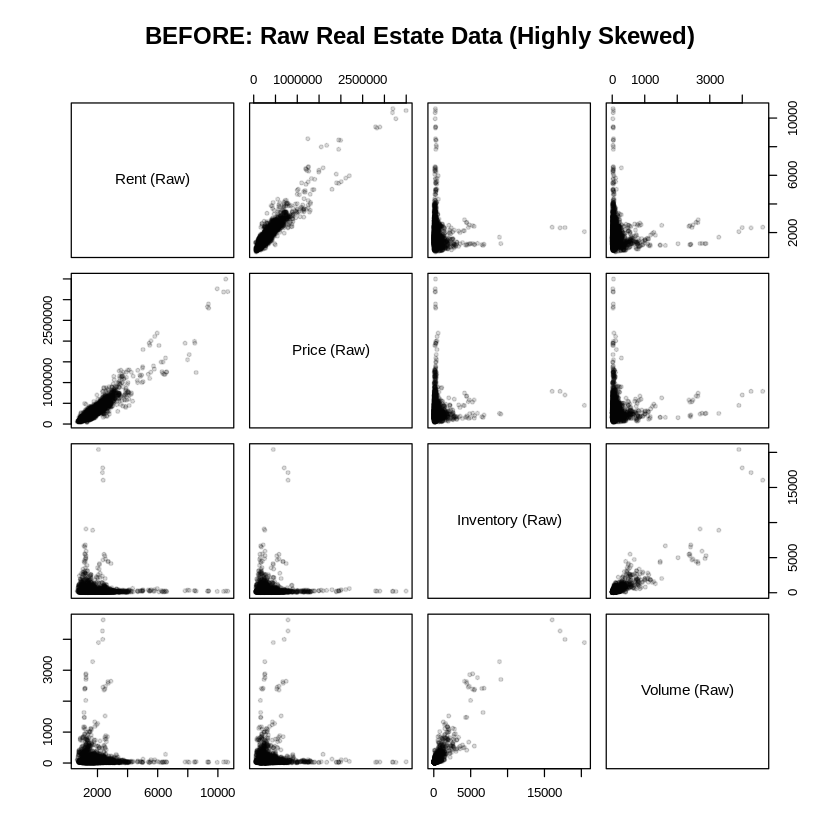

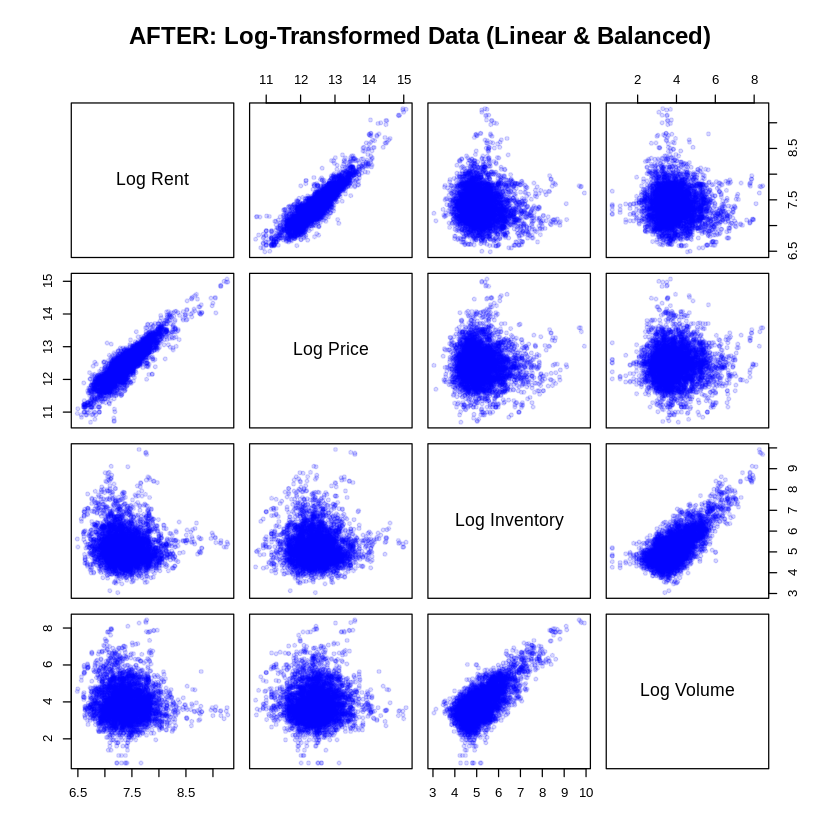

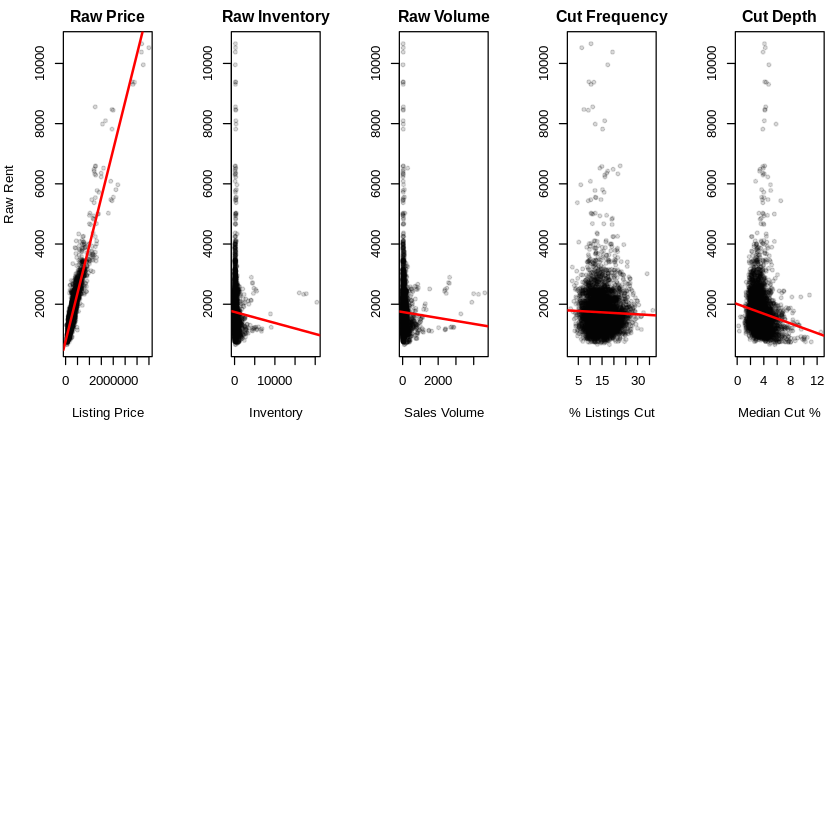

In [4]:
print("Fetching pre-compiled GBM from Ubuntu servers...")
system("sudo apt-get update", intern=TRUE)
system("sudo apt-get install -y r-cran-car", intern=TRUE)
system("sudo apt-get install -y r-cran-corrplot", intern=TRUE)

required_packages <- c("corrplot", "car", "ggplot2")

# Loop through, install if missing, and load them
for (pkg in required_packages) {
  if (!require(pkg, character.only = TRUE)) {
    install.packages(pkg, repos = "http://cran.us.r-project.org", quiet = TRUE)
    library(pkg, character.only = TRUE)
  }
}
print("All packages successfully installed and loaded.")

df_raw <- df
features <- c(
    "Date",
    "Sale_Counts_Seas_Adj",
    "InventorySeasonallyAdjusted_AllHomes",
    "MedianListingPrice_AllHomes",
    "PriceToRentRatio_AllHomes",
    "PctOfListingsWithPriceReductions_AllHomes",
    "MedianPctOfPriceReduction_AllHomes",
    "ZRI_AllHomes"
)
df <- df_raw[, features]
df <- na.omit(df)
df$log_Sale_Counts <- log(df$Sale_Counts_Seas_Adj + 1)
df$log_Inventory <- log(df$InventorySeasonallyAdjusted_AllHomes + 1)
df$log_ListingPrice <- log(df$MedianListingPrice_AllHomes)
df$log_ZRI <- log(df$ZRI_AllHomes)
nrow(df)
# df$RegionName <- as.factor(df$RegionName)
# Fit the Full Rent Model
# Note: We drop PriceToRentRatio since PTRR can be directly calculated via ZRI
# & vice versa.
model_rent_full <- lm(log_ZRI ~ log_ListingPrice + log_Inventory + log_Sale_Counts +
                      PctOfListingsWithPriceReductions_AllHomes +
                      MedianPctOfPriceReduction_AllHomes,
                      data = df)

numeric_vars <- df[, c("log_ZRI", "log_ListingPrice", "log_Inventory",
                       "log_Sale_Counts", "PctOfListingsWithPriceReductions_AllHomes",
                       "MedianPctOfPriceReduction_AllHomes")]

# Rename columns for presentation plot
colnames(numeric_vars) <- c("Rent", "Listing Price", "Inventory", "Sales Volume", "Price Cut Freq", "Price Cut Depth")
cor_matrix <- cor(numeric_vars, use = "complete.obs")
corrplot(cor_matrix, method = "color", type = "upper",
         addCoef.col = "black", # Adds the actual numbers
         tl.col = "black", tl.srt = 45, # Rotates text
         title = "Macroeconomic Correlations", mar=c(0,0,2,0))

# random sample of 5k to reduce load time, seed so report and presentation
# look the same
set.seed(42)

vif(model_rent_full)

df_sample <- df[sample(nrow(df), 5000), ]
raw_vars <- c("ZRI_AllHomes", "MedianListingPrice_AllHomes",
              "InventorySeasonallyAdjusted_AllHomes", "Sale_Counts_Seas_Adj")

log_vars <- c("log_ZRI", "log_ListingPrice", "log_Inventory", "log_Sale_Counts")

# Raw Data
pairs(df_sample[, raw_vars],
      main = "BEFORE: Raw Real Estate Data (Highly Skewed)",
      pch = 20, col = rgb(0, 0, 0, 0.15),
      labels = c("Rent (Raw)", "Price (Raw)", "Inventory (Raw)", "Volume (Raw)"))

# Log Transformed
pairs(df_sample[, log_vars],
      main = "AFTER: Log-Transformed Data (Linear & Balanced)",
      pch = 20, col = rgb(0, 0, 1, 0.15),
      labels = c("Log Rent", "Log Price", "Log Inventory", "Log Volume"))
par(mfrow=c(2, 5), mar=c(4, 4, 2, 1))
plot(df_sample$MedianListingPrice_AllHomes, df_sample$ZRI_AllHomes,
     main="Raw Price", xlab="Listing Price", ylab="Raw Rent", pch=20, col=rgb(0,0,0,0.15))
abline(lm(ZRI_AllHomes ~ MedianListingPrice_AllHomes, data=df_sample), col="red", lwd=2)

# Raw Inventory
plot(df_sample$InventorySeasonallyAdjusted_AllHomes, df_sample$ZRI_AllHomes,
     main="Raw Inventory", xlab="Inventory", ylab="", pch=20, col=rgb(0,0,0,0.15))
abline(lm(ZRI_AllHomes ~ InventorySeasonallyAdjusted_AllHomes, data=df_sample), col="red", lwd=2)

# Raw Sales Volume
plot(df_sample$Sale_Counts_Seas_Adj, df_sample$ZRI_AllHomes,
     main="Raw Volume", xlab="Sales Volume", ylab="", pch=20, col=rgb(0,0,0,0.15))
abline(lm(ZRI_AllHomes ~ Sale_Counts_Seas_Adj, data=df_sample), col="red", lwd=2)

# Raw Cut Frequency
plot(df_sample$PctOfListingsWithPriceReductions_AllHomes, df_sample$ZRI_AllHomes,
     main="Cut Frequency", xlab="% Listings Cut", ylab="", pch=20, col=rgb(0,0,0,0.15))
abline(lm(ZRI_AllHomes ~ PctOfListingsWithPriceReductions_AllHomes, data=df_sample), col="red", lwd=2)

# Raw Cut Depth
plot(df_sample$MedianPctOfPriceReduction_AllHomes, df_sample$ZRI_AllHomes,
     main="Cut Depth", xlab="Median Cut %", ylab="", pch=20, col=rgb(0,0,0,0.15))
abline(lm(ZRI_AllHomes ~ MedianPctOfPriceReduction_AllHomes, data=df_sample), col="red", lwd=2)



FULL RENT MODEL (log_ZRI)


,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),-0.078241513,1.271211e-02,-6.154880,7.541244e-10
log_ListingPrice,0.598644673,9.147404e-04,654.442175,0.000000e+00
log_Inventory,-0.025917694,8.173160e-04,-31.710738,1.295343e-219
log_Sale_Counts,-0.002224065,7.151545e-04,-3.109908,1.871967e-03
PctOfListingsWithPriceReductions_AllHomes,0.002897443,9.734728e-05,29.763987,7.739280e-194
MedianPctOfPriceReduction_AllHomes,0.034729233,4.268509e-04,81.361505,0.000000e+00


[1] 0.8209635

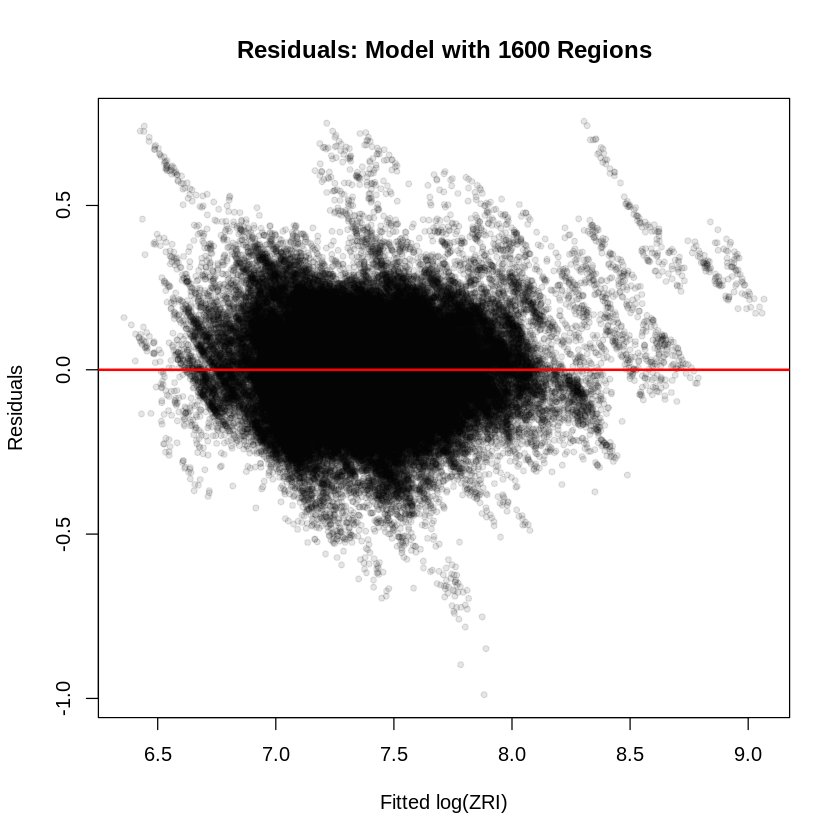

In [5]:
cat("\nFULL RENT MODEL (log_ZRI)\n")

summary(model_rent_full)$coefficients[1:6, ]
summary(model_rent_full)$adj.r.squared
plot(fitted(model_rent_full), resid(model_rent_full),
     main="Residuals: Model with 1600 Regions",
     xlab="Fitted log(ZRI)", ylab="Residuals",
     pch = 20, col = rgb(0,0,0,0.1))
abline(h = 0, col = "red", lwd = 2)
model_rent_red1 <- lm(log_ZRI ~ log_ListingPrice + log_Inventory + log_Sale_Counts, data = df)
model_rent_red2 <- lm(log_ZRI ~ log_ListingPrice +
                      PctOfListingsWithPriceReductions_AllHomes +
                      MedianPctOfPriceReduction_AllHomes
                      , data = df)
model_rent_red3 <- lm(log_ZRI ~ log_Inventory + log_Sale_Counts +
                        PctOfListingsWithPriceReductions_AllHomes +
                      MedianPctOfPriceReduction_AllHomes, data = df)





PARTIAL F-TEST 1:  Price Reduction Metrics


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,102234,2208.240,NA,NA,NA,NA
2,102232,2068.853,2,139.3877,3443.909,0



PARTIAL F-TEST 2: Inventory & Sale Counts


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,102234,2119.138,NA,NA,NA,NA
2,102232,2068.853,2,50.28487,1242.409,0



PARTIAL F-TEST 3: 'PctOfListingsWithPriceReductions'


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,102233,10736.181,NA,NA,NA,NA
2,102232,2068.853,1,8667.329,428294.6,0


Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




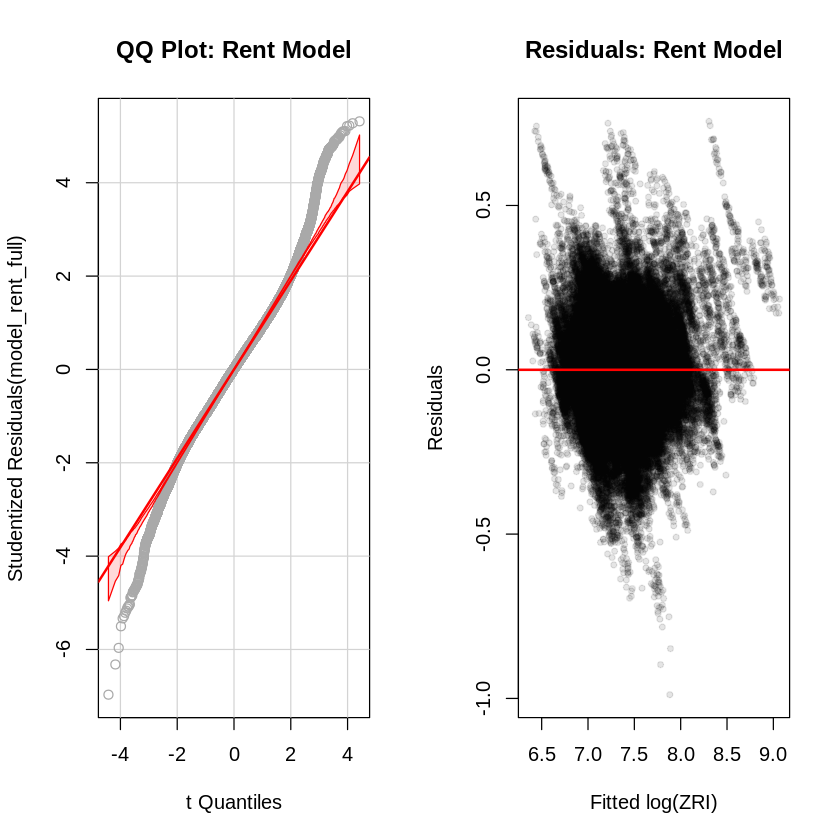

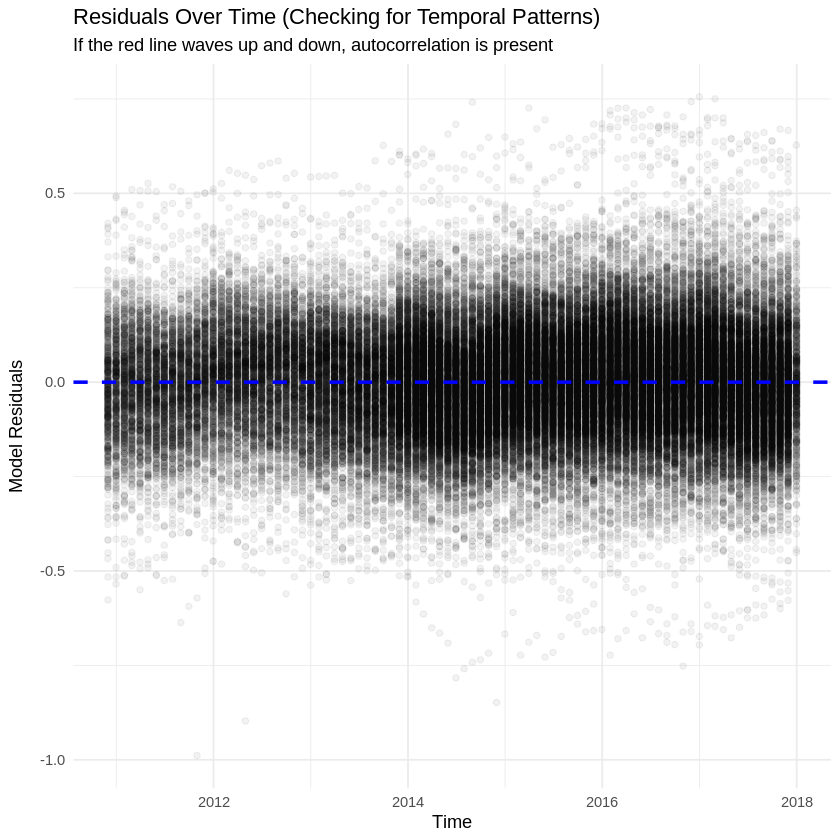

In [6]:
cat("\nPARTIAL F-TEST 1:  Price Reduction Metrics\n")
anova(model_rent_red1, model_rent_full)

cat("\nPARTIAL F-TEST 2: Inventory & Sale Counts\n")
anova(model_rent_red2, model_rent_full)

cat("\nPARTIAL F-TEST 3: 'PctOfListingsWithPriceReductions'\n")
anova(model_rent_red3, model_rent_full)
par(mfrow=c(1,2))
qqPlot(model_rent_full, id=FALSE, main="QQ Plot: Rent Model", col="darkgray", col.lines="red")
plot(fitted(model_rent_full), resid(model_rent_full),
     main="Residuals: Rent Model", xlab="Fitted log(ZRI)", ylab="Residuals",
     pch = 20, col = rgb(0,0,0,0.1))
abline(h = 0, col = "red", lwd = 2)
library(lmtest)
library(ggplot2)
df$Model_Residuals <- resid(model_rent_full)
df$DateColumn <- as.Date(df$Date)
ggplot(df, aes(x = DateColumn, y = Model_Residuals)) +
  geom_point(alpha = 0.05, color = "black") +
  geom_hline(yintercept = 0, color = "blue", linetype = "dashed", linewidth = 1) +
  theme_minimal() +
  labs(title = "Residuals Over Time (Checking for Temporal Patterns)",
       subtitle = "If the red line waves up and down, autocorrelation is present",
       x = "Time",
       y = "Model Residuals")
par(mfrow = c(4, 2), mar = c(4, 4, 3, 1))


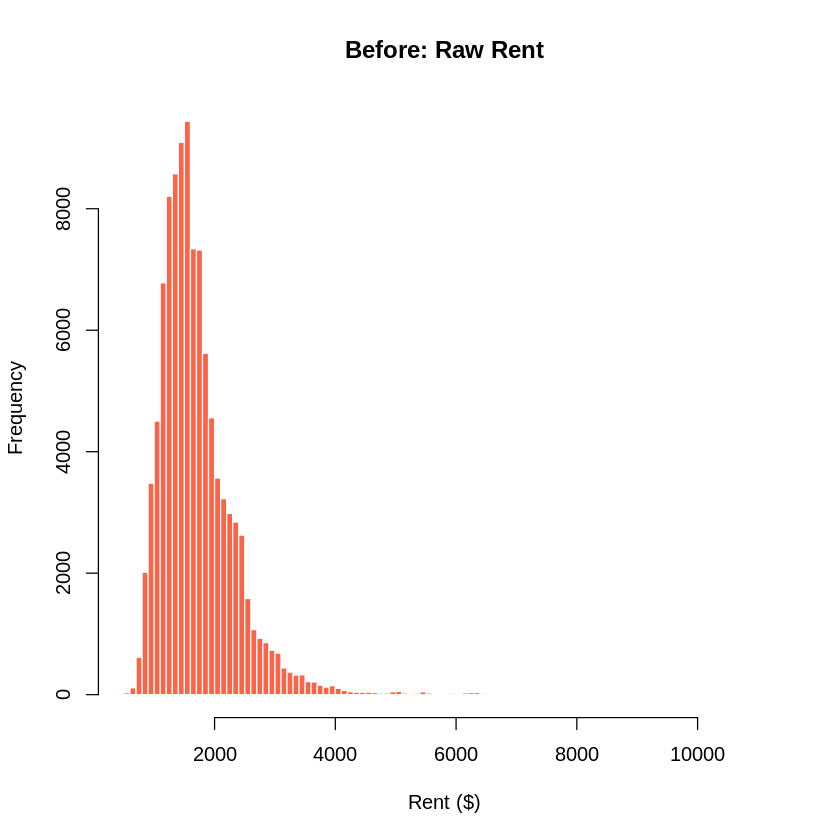

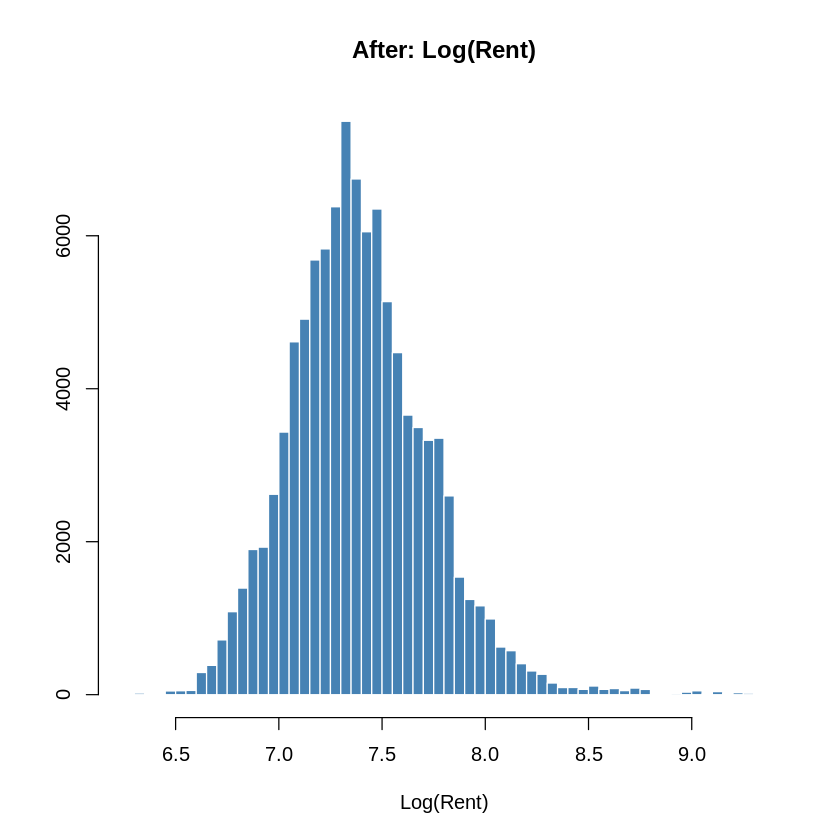

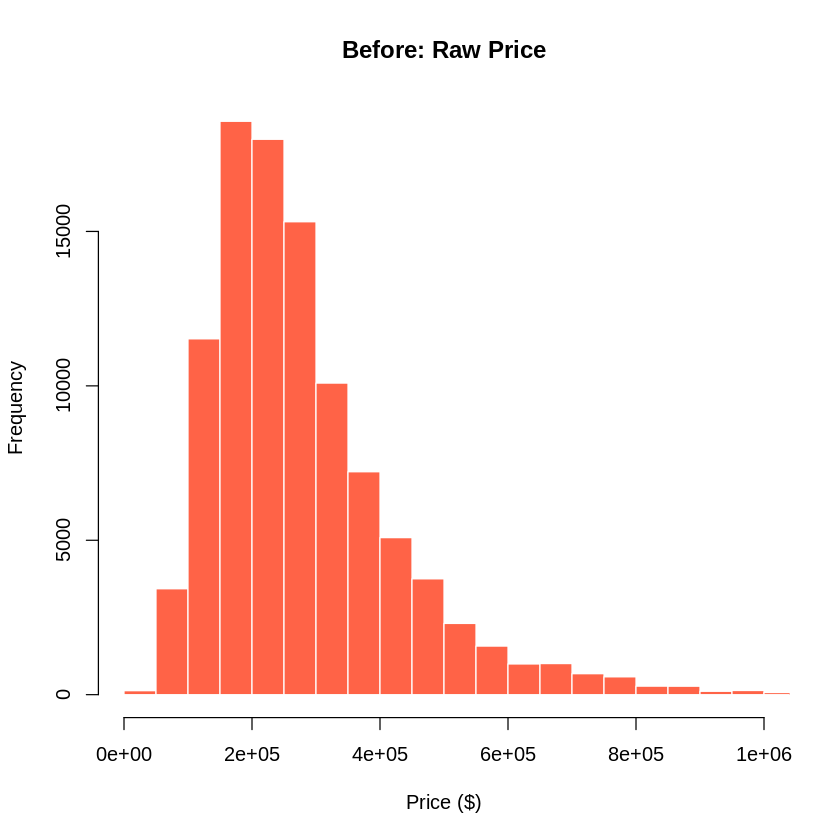

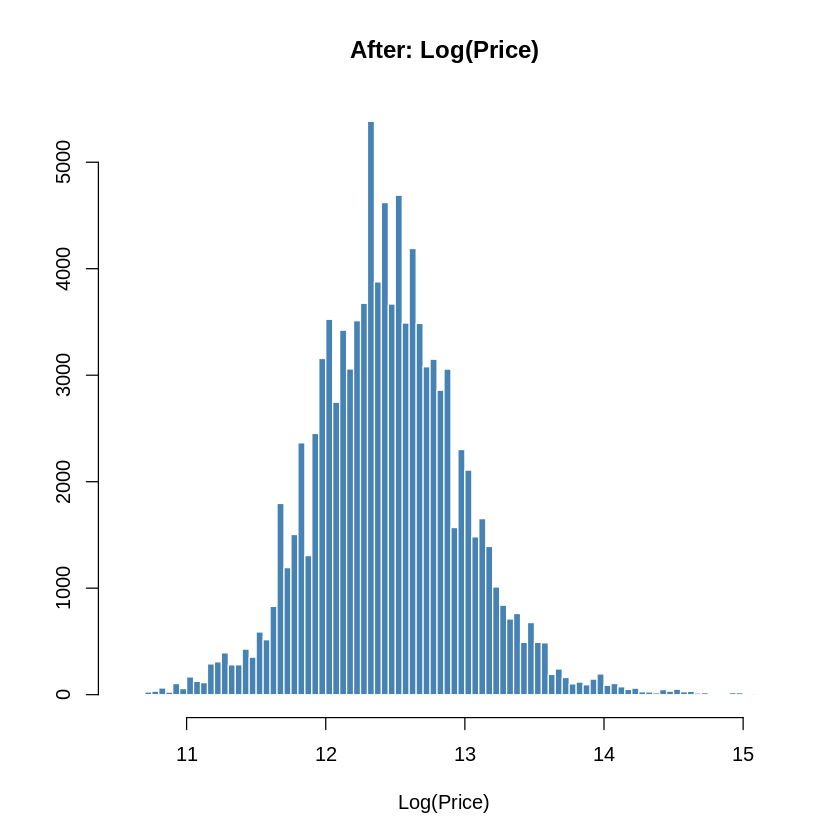

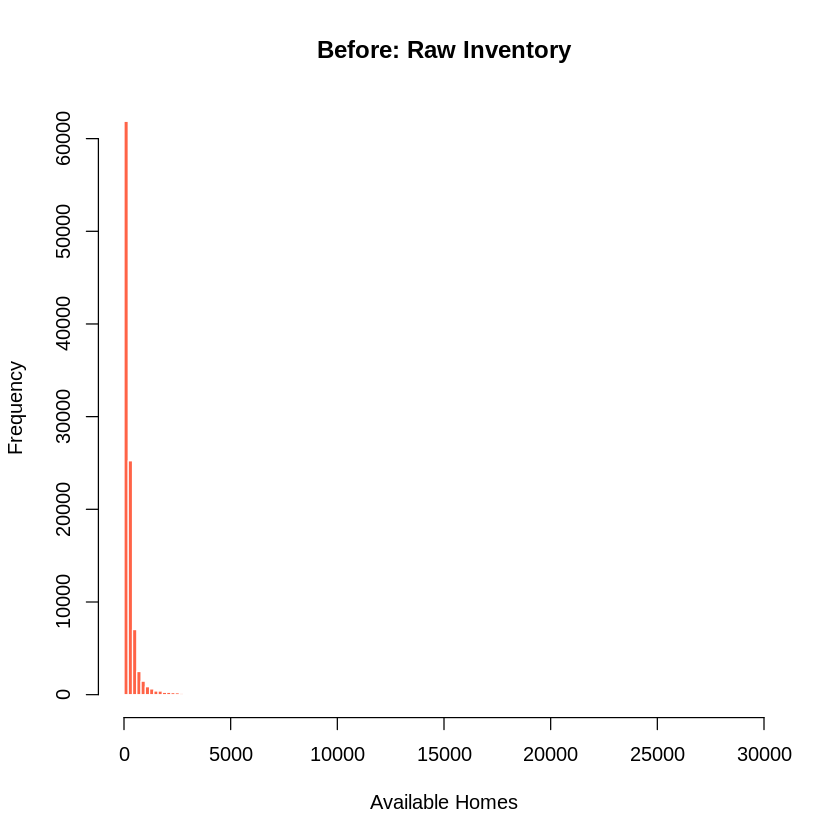

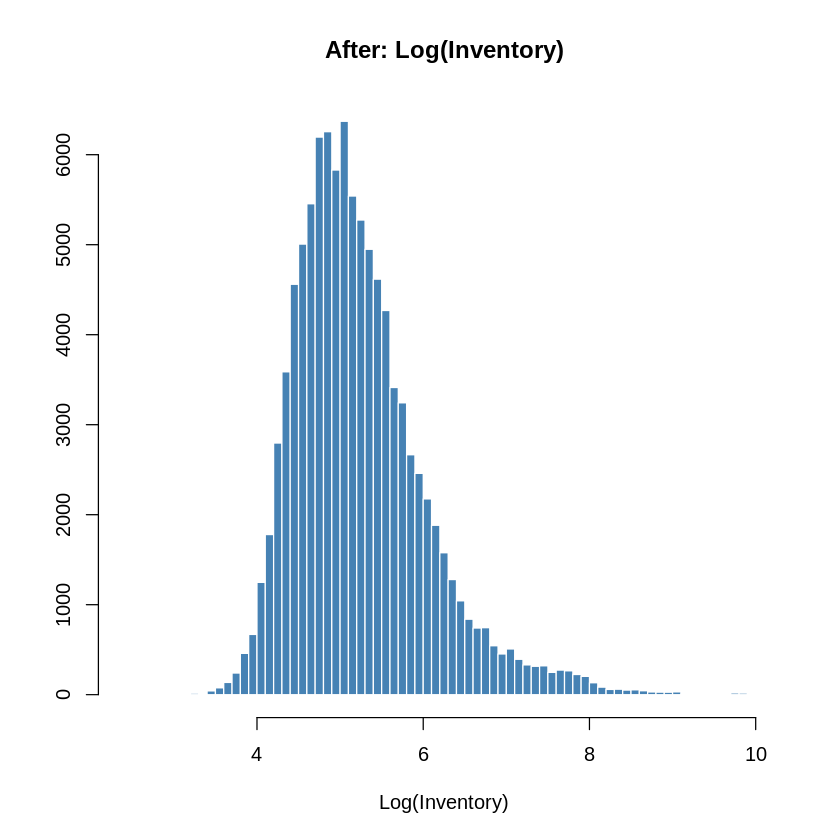

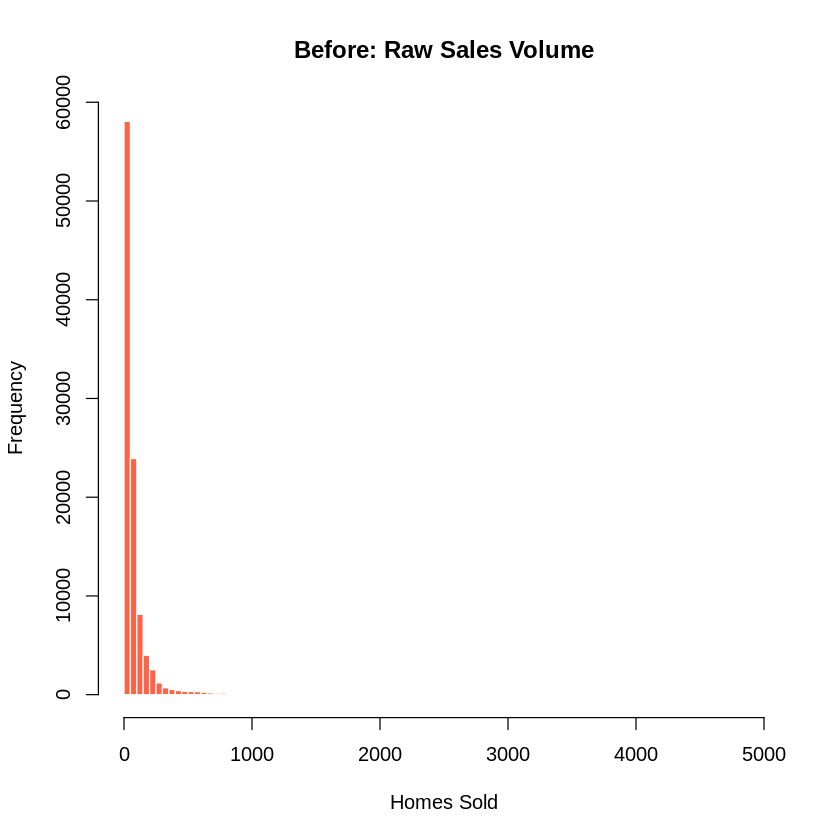

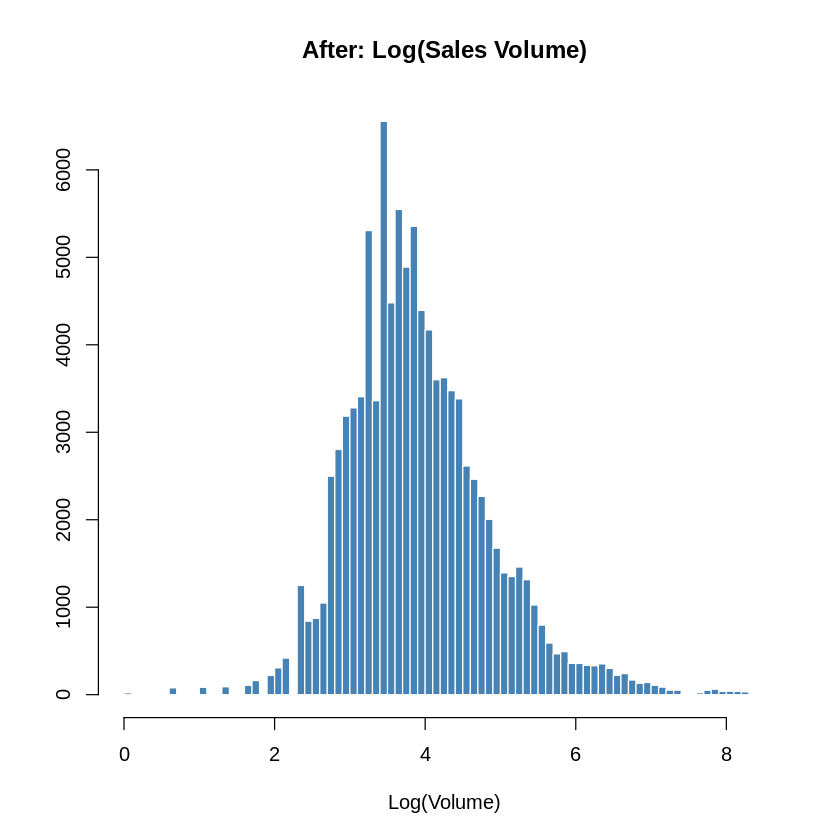

In [7]:
# Rent Index (ZRI)
hist(df$ZRI_AllHomes, breaks = 100, col = "tomato", border = "white",
     main = "Before: Raw Rent", xlab = "Rent ($)", ylab = "Frequency")

hist(df$log_ZRI, breaks = 100, col = "steelblue", border = "white",
     main = "After: Log(Rent)", xlab = "Log(Rent)", ylab = "")

# Listing Price
hist(df$MedianListingPrice_AllHomes, breaks = 100, col = "tomato", border = "white",
     main = "Before: Raw Price", xlab = "Price ($)", ylab = "Frequency",
     xlim = c(0, 1000000)) # Capped for readability

hist(df$log_ListingPrice, breaks = 100, col = "steelblue", border = "white",
     main = "After: Log(Price)", xlab = "Log(Price)", ylab = "")

# Market Inventory
hist(df$InventorySeasonallyAdjusted_AllHomes, breaks = 100, col = "tomato", border = "white",
     main = "Before: Raw Inventory", xlab = "Available Homes", ylab = "Frequency",
     xlim = c(0, 30000)) # Capped for readability

hist(df$log_Inventory, breaks = 100, col = "steelblue", border = "white",
     main = "After: Log(Inventory)", xlab = "Log(Inventory)", ylab = "")
# Sales Volume
hist(df$Sale_Counts_Seas_Adj, breaks = 100, col = "tomato", border = "white",
     main = "Before: Raw Sales Volume", xlab = "Homes Sold", ylab = "Frequency",
     xlim = c(0, 5000)) # Capped for readability

hist(df$log_Sale_Counts, breaks = 100, col = "steelblue", border = "white",
     main = "After: Log(Sales Volume)", xlab = "Log(Volume)", ylab = "")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


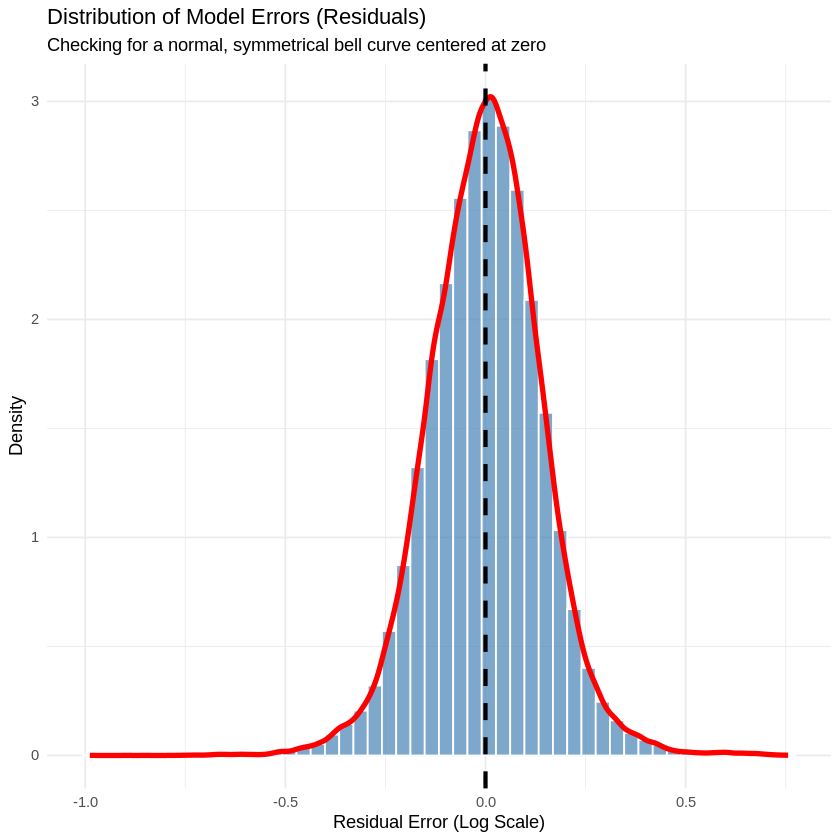

In [8]:
install.packages("ggplot2")
library(ggplot2)

# Extract the residuals from model into a dataframe
res_data <- data.frame(Errors = resid(model_rent_full))

# Plot the Histogram with a Density Curve overlaid
ggplot(res_data, aes(x = Errors)) +
  # Draw the histogram bars (using density instead of count for the y-axis)
  geom_histogram(aes(y = after_stat(density)), bins = 50, fill = "steelblue", color = "white", alpha = 0.7) +
  # Draw a smooth red density line over the bars to see the shape clearly
  geom_density(color = "red", size = 1.5) +
  # Draw a dashed black line straight down the middle at zero
  geom_vline(xintercept = 0, color = "black", linetype = "dashed", size = 1.2) +
  theme_minimal() +
  labs(title = "Distribution of Model Errors (Residuals)",
       subtitle = "Checking for a normal, symmetrical bell curve centered at zero",
       x = "Residual Error (Log Scale)",
       y = "Density")


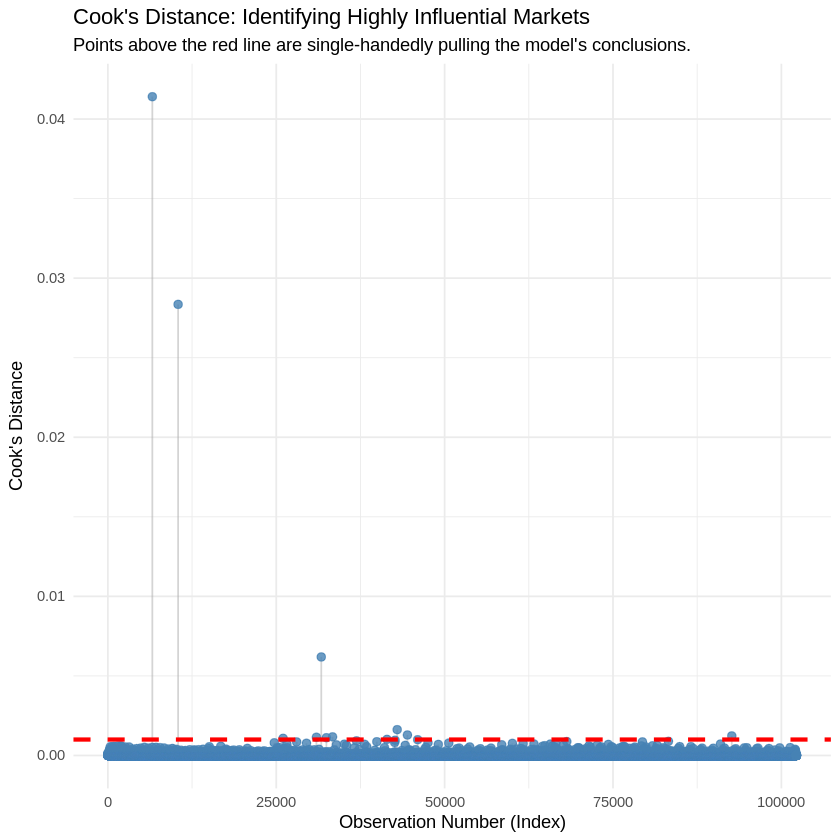


Call:
lm(formula = log_ZRI ~ log_ListingPrice + log_Inventory + log_Sale_Counts + 
    PctOfListingsWithPriceReductions_AllHomes + MedianPctOfPriceReduction_AllHomes, 
    data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.98852 -0.09045  0.00203  0.08971  0.75599 

Coefficients:
                                            Estimate Std. Error t value
(Intercept)                               -7.824e-02  1.271e-02  -6.155
log_ListingPrice                           5.986e-01  9.147e-04 654.442
log_Inventory                             -2.592e-02  8.173e-04 -31.711
log_Sale_Counts                           -2.224e-03  7.152e-04  -3.110
PctOfListingsWithPriceReductions_AllHomes  2.897e-03  9.735e-05  29.764
MedianPctOfPriceReduction_AllHomes         3.473e-02  4.268e-04  81.362
                                          Pr(>|t|)    
(Intercept)                               7.54e-10 ***
log_ListingPrice                           < 2e-16 ***
log_Inventory               

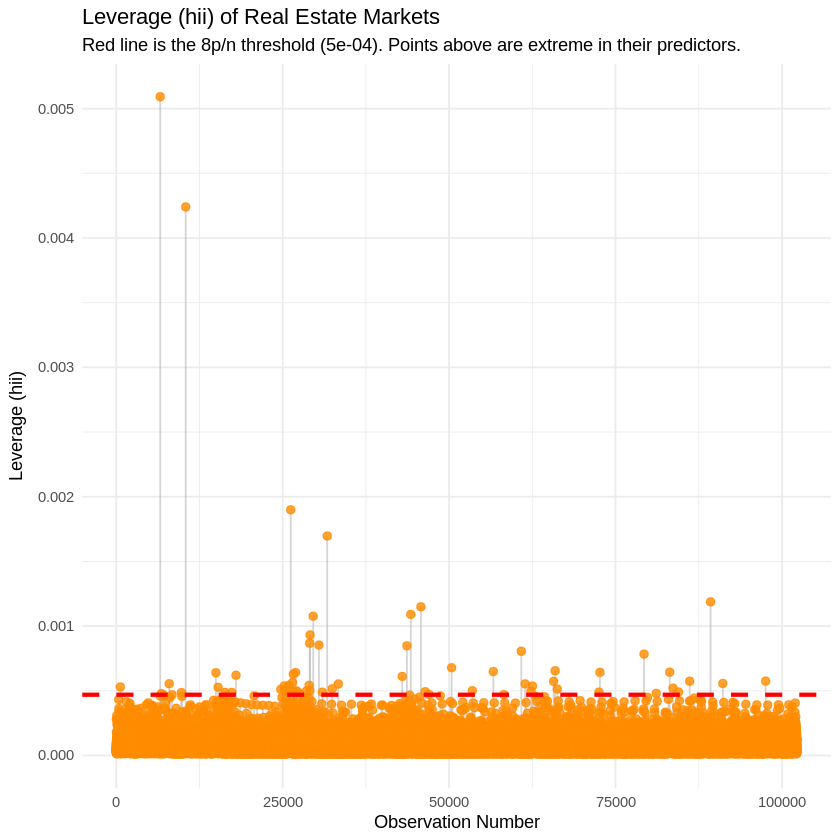

In [9]:
cooks_d <- cooks.distance(model_rent_full)

# Create a clean dataframe for plotting
df_cooks <- data.frame(
  Observation = 1:length(cooks_d),
  Cooks_Distance = cooks_d
)
threshold <- .001
ggplot(df_cooks, aes(x = Observation, y = Cooks_Distance)) +
  # Draw the stems connecting points to zero
  geom_segment(aes(xend = Observation, yend = 0), color = "darkgray", alpha = 0.5) +
  # Draw the actual data points
  geom_point(color = "steelblue", size = 2, alpha = 0.8) +
  # Draw the red danger threshold line
  geom_hline(yintercept = threshold, color = "red", linetype = "dashed", size = 1.2) +
  theme_minimal() +
  labs(title = "Cook's Distance: Identifying Highly Influential Markets",
       subtitle = "Points above the red line are single-handedly pulling the model's conclusions.",
       y = "Cook's Distance",
       x = "Observation Number (Index)")

hii <- hatvalues(model_rent_full)

# Calculate 'p' (Number of parameters, including intercept)
p <- length(coef(model_rent_full))
n <- nrow(df)

threshold_hii <- 8 * (p / n)

# Create a clean dataframe for plotting
df_leverage <- data.frame(
  Observation = 1:length(hii),
  Leverage = hii
)

# Plot the Leverage
ggplot(df_leverage, aes(x = Observation, y = Leverage)) +
  geom_segment(aes(xend = Observation, yend = 0), color = "darkgray", alpha = 0.5) +
  geom_point(color = "darkorange", size = 2, alpha = 0.8) +
  # Draw  3p/n threshold line
  geom_hline(yintercept = threshold_hii, color = "red", linetype = "dashed", size = 1.2) +
  theme_minimal() +
  labs(title = "Leverage (hii) of Real Estate Markets",
       subtitle = paste("Red line is the 8p/n threshold (", round(threshold_hii, 4), "). Points above are extreme in their predictors.", sep=""),
       y = "Leverage (hii)",
       x = "Observation Number")

summary(model_rent_full)